In [4]:
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
import numpy as np

from dla.simulate import simulate_dla, parents_to_graph

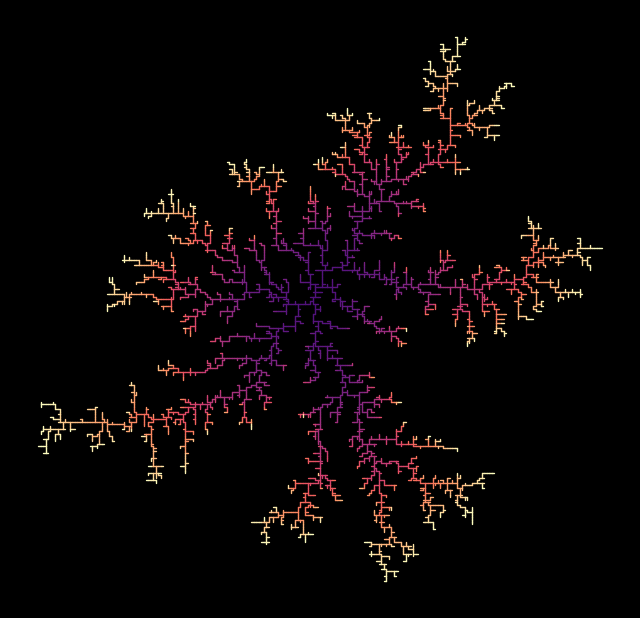

In [5]:
from matplotlib.colors import ListedColormap

# magma without its darkest quarter, so the core stays visible on black
CMAP = ListedColormap(plt.cm.magma(np.linspace(0.25, 1, 256)))


def plot_dla(parents, directions, ax=None):
    grid = parents_to_graph(parents, directions)
    n = len(parents)
    xs, ys = np.nonzero(grid)
    coords = np.empty((n, 2))
    coords[grid[xs, ys] - 1] = np.column_stack([xs, ys])  # row k = node k+1

    segments = np.stack([coords[parents[1:] - 1], coords[1:]], axis=1)
    lines = LineCollection(segments, cmap=CMAP, linewidths=1.0, capstyle="round")
    lines.set_array(np.arange(1, n))  # color by arrival time

    ax = ax or plt.gca()
    ax.set_facecolor("black")
    ax.add_collection(lines)
    ax.set_aspect("equal")
    ax.autoscale()
    ax.set_xticks([])
    ax.set_yticks([])
    return ax


fig, ax = plt.subplots(figsize=(8, 8), facecolor="black")
plot_dla(*simulate_dla(5000, simulator_seed=42), ax=ax)
plt.show()

In [ ]:
import time

simulate_dla(10, simulator_seed=0)  # compile once so it isn't counted below

sizes = [1_000, 5_000, 10_000, 20_000]
graphs_per_size = 5

print(f"{'nodes':>7} {'graphs':>6} {'total s':>8} {'mean s':>7} {'min s':>7} {'max s':>7} {'us/node':>8}")
for num_nodes in sizes:
    times = []
    for seed in range(graphs_per_size):
        start = time.perf_counter()
        simulate_dla(num_nodes, simulator_seed=seed)
        times.append(time.perf_counter() - start)
    times = np.array(times)
    print(
        f"{num_nodes:>7} {graphs_per_size:>6} {times.sum():>8.3f} {times.mean():>7.3f} "
        f"{times.min():>7.3f} {times.max():>7.3f} {1e6 * times.mean() / num_nodes:>8.1f}"
    )